In [1]:
# Imports.
import numpy as np;
import matplotlib.pyplot as plt;
from ipywidgets import FloatSlider, VBox, HBox, interactive_output;
from IPython.display import display;

# Styling.
plt.style.use("bmh");
%matplotlib widget

In [2]:
# -------------------------------------------------------------------
# -------- ----------------Globals/constants. -----------------------
# -------------------------------------------------------------------

physical_constants = {
	"elementary_charge" : 1.602176634e-19,
	"proton_mass" : 1.67262192369e-27,
	"speed_of_light": 3e8,
};

machine_specific_constants = {
	"magnetic_field_on_axis" : 5.3,
	"major_radius" : 6.0,
	"safety_factor": 3.5,
	"aspect_ratio" : 3.1,
}

gam_specific_constants = {
	"radial_wavenumber" : 10,
	"parallel_velocity" : 1e5,
	"perpendicular_velocity": 1e5
};

In [3]:
# -------------------------------------------------------------------
# -------- --------------Definitions (circular). --------------------
# -------------------------------------------------------------------

# Defaults are set to ITER-like values for all methods.
def transit_frequency_circular(q = None):

	v_par = gam_specific_constants["parallel_velocity"];
	q = machine_specific_constants["safety_factor"] if q is None else q;
	R_0 = machine_specific_constants["major_radius"];
	epsilon = 1 / machine_specific_constants["aspect_ratio"];

	# Standard definition of omega_t = v_par / qR_0.
	# We include this geometric prefactor to match Chen's result.
	geometric_factor = (1 + 0.5 * epsilon ** 2);
	return v_par * geometric_factor / (q * R_0);

def drift_frequency_circular(theta, ion_mass_prefactor = 2.5):
	# Using SI conventions, so we exclude the factor of c.
	m_i = ion_mass_prefactor * physical_constants["proton_mass"];
	e = physical_constants["elementary_charge"];
	k_r = gam_specific_constants["radial_wavenumber"];
	B_0 = machine_specific_constants["magnetic_field_on_axis"];
	R_0 = machine_specific_constants["major_radius"];
	v_par = gam_specific_constants["parallel_velocity"];
	v_perp = gam_specific_constants["perpendicular_velocity"];
	Z = 1;

	# Standard definition of omega_d = (k_rm / ZeB_0R_0) * (v_par^2 + v_perp^2/2).
	prefactor = (k_r * m_i) / (Z * e * B_0 * R_0);
	velocity_term = (v_par ** 2 + (v_perp ** 2) / 2);
	geometric_factor = np.sin(theta);
	return prefactor * velocity_term * geometric_factor;

In [4]:
# -------------------------------------------------------------------
# -------- --------------Definitions (Chen 2023). -------------------
# -------------------------------------------------------------------

def q_hat_chen(delta, kappa, Delta_prime, s_kappa = None, s_delta = None, q = None):

	epsilon = 1 / machine_specific_constants["aspect_ratio"];
	q = machine_specific_constants["safety_factor"] if q is None else q;
	# Typical empirical values for s_kappa and s_delta.
	s_kappa = (kappa - 1) / kappa if s_kappa is None else s_kappa;
	s_delta = delta if s_delta is None else s_delta;
	delta_star = delta - s_delta;

	denominator = (1.0 + 0.5 * s_kappa + 0.5 * epsilon * delta - 0.125 * epsilon * delta_star + 0.5 * epsilon ** 2 
				- 0.5 * epsilon * Delta_prime - 0.25 * delta**2 + 0.125 * delta * delta_star);
	return q / denominator;

def frequency_denominator_chen(theta, delta, kappa, Delta_prime, s_kappa = None, s_delta = None):

	s_kappa = (kappa - 1) / kappa if s_kappa is None else s_kappa;
	s_delta = delta if s_delta is None else s_delta;
	delta_star = delta - s_delta;

	sin  = np.sin(theta);
	cosine  = np.cos(theta);
	sin_squared = sin ** 2;
	cos_squared = cosine ** 2;
	denominator = (1.0 + Delta_prime * cosine + s_kappa * sin_squared + (delta_star + 2.0 * s_kappa * delta) * sin_squared * cosine 
				- 0.5 * delta * (delta - 2.0 * delta_star) * sin_squared * cos_squared - 0.5 * delta**2 * sin_squared ** 2);
	return denominator;

def transit_frequency_chen(theta, delta, kappa, Delta_prime, s_kappa = None, s_delta = None, q = None):

	v_par = gam_specific_constants["parallel_velocity"];
	q = machine_specific_constants["safety_factor"] if q is None else q;
	R_0 = machine_specific_constants["major_radius"];

	q_hat = q_hat_chen(delta, kappa, Delta_prime, s_kappa, s_delta, q);
	denominator = frequency_denominator_chen(theta, delta, kappa, Delta_prime, s_kappa, s_delta);
	return v_par / (q_hat * denominator * R_0);

def drift_frequency_chen(theta, delta, kappa, Delta_prime, s_kappa = None, s_delta = None, ion_mass_prefactor = 2.5):

	# Using SI conventions, so we exclude the factor of c.
	m_i = ion_mass_prefactor * physical_constants["proton_mass"];
	e = physical_constants["elementary_charge"];
	k_r = gam_specific_constants["radial_wavenumber"];
	B_0 = machine_specific_constants["magnetic_field_on_axis"];
	R_0 = machine_specific_constants["major_radius"];
	v_par = gam_specific_constants["parallel_velocity"];
	v_perp = gam_specific_constants["perpendicular_velocity"];
	Z = 1;

	prefactor = (k_r * m_i) / (2.0 * kappa * Z * e * B_0 * R_0);
	velocity_term = (2.0 * v_par ** 2 + (v_perp ** 2));
	denominator = frequency_denominator_chen(theta, delta, kappa, Delta_prime, s_kappa, s_delta);
	geometric_term = (np.sin(theta) + delta * np.sin(2.0 * theta) - 0.125 * delta ** 2 * np.sin(theta) 
				   + (3.0 / 8.0) * delta ** 2 * np.sin(3.0 * theta));
	return (prefactor * velocity_term * geometric_term) / denominator;

Output()

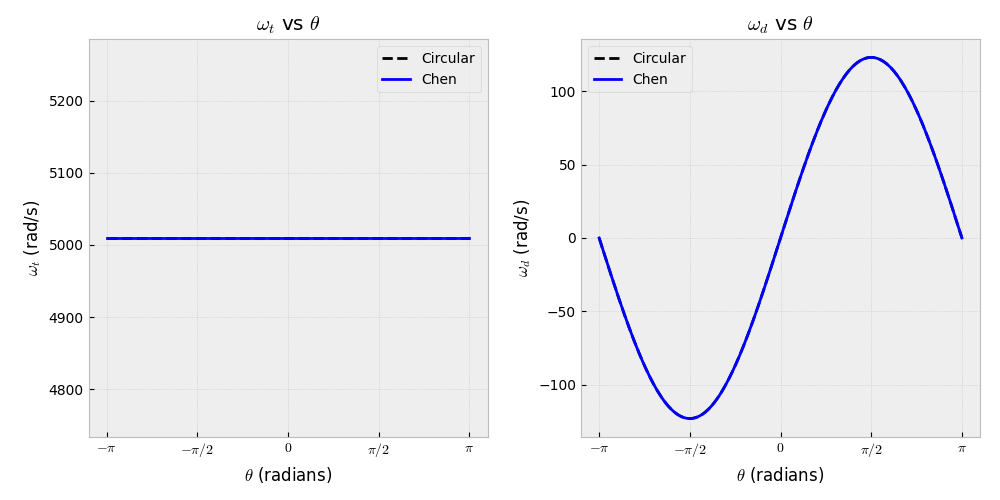

In [14]:
# -------------------------------------------------------------------
# -------- -------------Figure-plotting logic. ----------------------
# -------------------------------------------------------------------

theta = np.linspace(-np.pi, np.pi, 300);
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5));

# Initial dummy data.
line_transit_circular, = ax1.plot([], [], "k--", label="Circular");
line_transit_chen, = ax1.plot([], [], "b-", label="Chen");
line_drift_circular, = ax2.plot([], [], "k--", label="Circular");
line_drift_chen, = ax2.plot([], [], "b-", label="Chen");

for ax in [ax1, ax2]:
	ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi]);
	ax.set_xticklabels([r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"]);
	ax.grid(True, linestyle = ":", alpha = 0.7);
	ax.legend();

ax1.set_title(r"$\omega_t$ vs $\theta$")
ax1.set_xlabel(r"$\theta$ (radians)")
ax1.set_ylabel(r"$\omega_t$ (rad/s)")
ax2.set_title(r"$\omega_d$ vs $\theta$")
ax2.set_xlabel(r"$\theta$ (radians)")
ax2.set_ylabel(r"$\omega_d$ (rad/s)")
plt.tight_layout()

def update(delta, kappa, Delta_prime, q, s_kappa, s_delta):

	omega_t_circular_scalar = transit_frequency_circular(q);
	omega_t_circular = np.full_like(theta, omega_t_circular_scalar);
	omega_d_circular = drift_frequency_circular(theta);

	omega_t_chen = transit_frequency_chen(theta, delta, kappa, Delta_prime, s_kappa, s_delta, q);
	omega_d_chen = drift_frequency_chen(theta, delta, kappa, Delta_prime, s_kappa, s_delta);

	# Update existing lines outside of function scope.
	line_transit_circular.set_data(theta, omega_t_circular);
	line_transit_chen.set_data(theta, omega_t_chen);
	line_drift_circular.set_data(theta, omega_d_circular);
	line_drift_chen.set_data(theta, omega_d_chen);

	# Recalibrate x and y limits.
	ax1.relim();
	ax1.autoscale_view();
	ax2.relim();
	ax2.autoscale_view();

	# Redraw canvas.
	fig.canvas.draw_idle();

# Parameter sliders/widgets.
slider_delta = FloatSlider(
	value = 0.0, min=-0.5, max=0.5, step=0.05,
	description = "δ",
	continuous_update = True
);

slider_kappa = FloatSlider(
	value = 1.0, min = 1.0, max = 2.5, step=0.05,
	description = "κ",
	continuous_update = True
);

slider_Delta_prime = FloatSlider(
	value = 0.0, min = -0.6, max = 0, step = 0.05,
	description = "Δ'",
	continuous_update = True
);

slider_q = FloatSlider(
	value = 3.5, min = 1.0, max = 6.0, step = 0.1,
	description = "q",
	continuous_update = True
);

slider_s_kappa = FloatSlider(
	value = 0.0, min = 0, max = 1.0, step = 0.02,
	description = "s_κ",
	continuous_update = True
);

slider_s_delta = FloatSlider(
	value = 0.0, min = -0.5, max = 0.5, step = 0.05,
	description = "s_δ",
	continuous_update = True
);

# Display logic.
controls = VBox([
	HBox([slider_delta, slider_kappa, slider_Delta_prime]),
	HBox([slider_q, slider_s_kappa, slider_s_delta]),
])

out = interactive_output(update, {
	"delta": slider_delta,
	"kappa": slider_kappa,
	"Delta_prime": slider_Delta_prime,
	"q": slider_q,
	"s_kappa": slider_s_kappa,
	"s_delta": slider_s_delta,
});

display(controls, out);
# Initial draw.
update(
	slider_delta.value,
	slider_kappa.value,
	slider_Delta_prime.value,
	slider_q.value,
	slider_s_kappa.value,
	slider_s_delta.value
);

In [ ]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import FloatSlider, VBox, HBox, interactive_output
from IPython.display import display

# ------------------------------------------------------------
# Static setup
# ------------------------------------------------------------

theta = np.linspace(-np.pi, np.pi, 300)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Initial dummy data
line_t_circ, = ax1.plot([], [], "k--", label="Circular")
line_t_chen, = ax1.plot([], [], "b-", label="Chen")

line_d_circ, = ax2.plot([], [], "k--", label="Circular")
line_d_chen, = ax2.plot([], [], "b-", label="Chen")

# ------------------------------------------------------------
# Axis formatting (done ONCE)
# ------------------------------------------------------------

for ax in [ax1, ax2]:
    ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax.set_xticklabels([r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"])
    ax.grid(True, linestyle=":", alpha=0.7)
    ax.legend()

ax1.set_title(r"Transit Frequency ($\omega_t$) vs Poloidal Angle")
ax1.set_xlabel(r"$\theta$ (radians)")
ax1.set_ylabel(r"$\omega_t$ (rad/s)")

ax2.set_title(r"Magnetic Drift Frequency ($\omega_d$) vs Poloidal Angle")
ax2.set_xlabel(r"$\theta$ (radians)")
ax2.set_ylabel(r"$\omega_d$ (rad/s)")

plt.tight_layout()

# ------------------------------------------------------------
# Update function
# ------------------------------------------------------------

def update(delta, kappa, Delta_prime, q, s_kappa, s_delta):

    omega_t_circular_scalar = transit_frequency_circular(q)
    omega_t_circular = np.full_like(theta, omega_t_circular_scalar)

    omega_d_circular = drift_frequency_circular(theta)

    omega_t_chen = transit_frequency_chen(
        theta, delta, kappa, Delta_prime,
        s_kappa, s_delta, q
    )

    omega_d_chen = drift_frequency_chen(
        theta, delta, kappa, Delta_prime,
        s_kappa, s_delta
    )

    # Update existing lines
    line_t_circ.set_data(theta, omega_t_circular)
    line_t_chen.set_data(theta, omega_t_chen)

    line_d_circ.set_data(theta, omega_d_circular)
    line_d_chen.set_data(theta, omega_d_chen)

    # Rescale axes
    ax1.relim()
    ax1.autoscale_view()

    ax2.relim()
    ax2.autoscale_view()

    # Redraw canvas
    fig.canvas.draw_idle()

# ------------------------------------------------------------
# Widgets
# ------------------------------------------------------------

sl_delta = FloatSlider(
    value=0.33, min=0, max=0.5, step=0.01,
    description="δ",
    continuous_update=False
)

sl_kappa = FloatSlider(
    value=1.7, min=1.0, max=2.5, step=0.01,
    description="κ",
    continuous_update=False
)

sl_dprime = FloatSlider(
    value=-0.15, min=-0.5, max=0.1, step=0.01,
    description="Δ'",
    continuous_update=False
)

sl_q = FloatSlider(
    value=3.5, min=1.0, max=6.0, step=0.1,
    description="q",
    continuous_update=False
)

sl_sk = FloatSlider(
    value=0.33, min=0, max=0.5, step=0.01,
    description="s_κ",
    continuous_update=False
)

sl_sd = FloatSlider(
    value=0.33, min=0, max=0.5, step=0.01,
    description="s_δ",
    continuous_update=False
)

controls = VBox([
    HBox([sl_delta, sl_kappa, sl_dprime]),
    HBox([sl_q, sl_sk, sl_sd]),
])

out = interactive_output(update, {
    "delta": sl_delta,
    "kappa": sl_kappa,
    "Delta_prime": sl_dprime,
    "q": sl_q,
    "s_kappa": sl_sk,
    "s_delta": sl_sd,
})

display(controls, out)

# Initial draw
update(
    sl_delta.value,
    sl_kappa.value,
    sl_dprime.value,
    sl_q.value,
    sl_sk.value,
    sl_sd.value
)